In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# 1. Connect to the SQLite warehouse
conn = sqlite3.connect('../data/warehouse.db')
df = pd.read_sql_query("SELECT * FROM tickets", conn)
conn.close()

# Set visual style
sns.set_theme(style="whitegrid")

In [3]:
print(df.columns.tolist())
print(df.head(2))

['id', 'subject', 'body', 'answer', 'type', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']
     id                              subject  \
0  5430            Excessive Billing Inquiry   
1  6192  Detected Payment Processing Problem   

                                                body  \
0  There are unexpected charges on your monthly i...   
1  I encountered an unexpected payment failure du...   

                                              answer      type priority  \
0  Dear <name>, I am addressing the excessive bil...  Incident   medium   
1  I am here to assist you with the payment issue...  Incident   medium   

  language    tag_1     tag_2         tag_3       tag_4          tag_5 tag_6  \
0       en  Billing  Customer        Outage  Resolution           None  None   
1       en  Billing   Payment  Subscription    Guidance  Documentation  None   

  tag_7 tag_8  
0  None  None  
1  None  None  


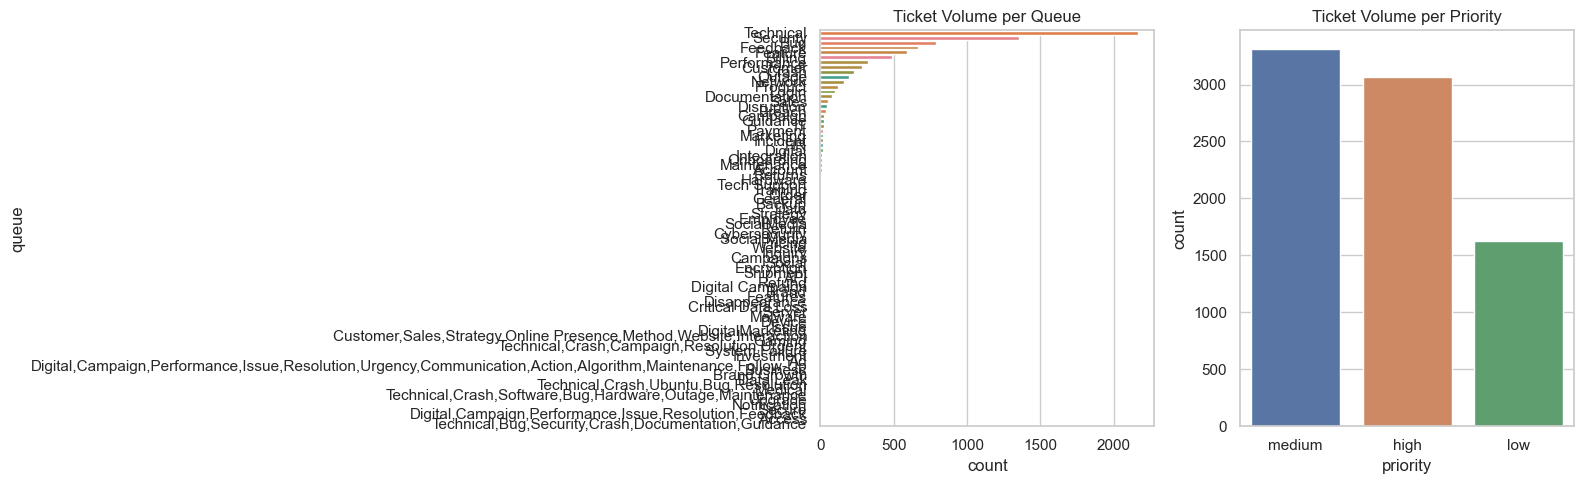

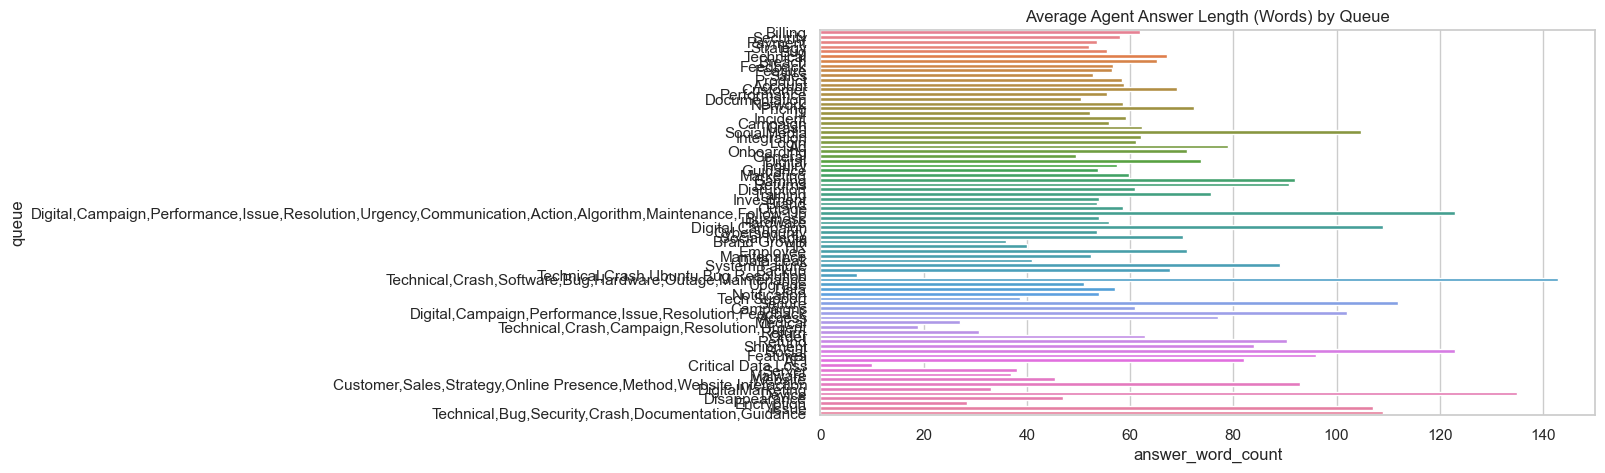

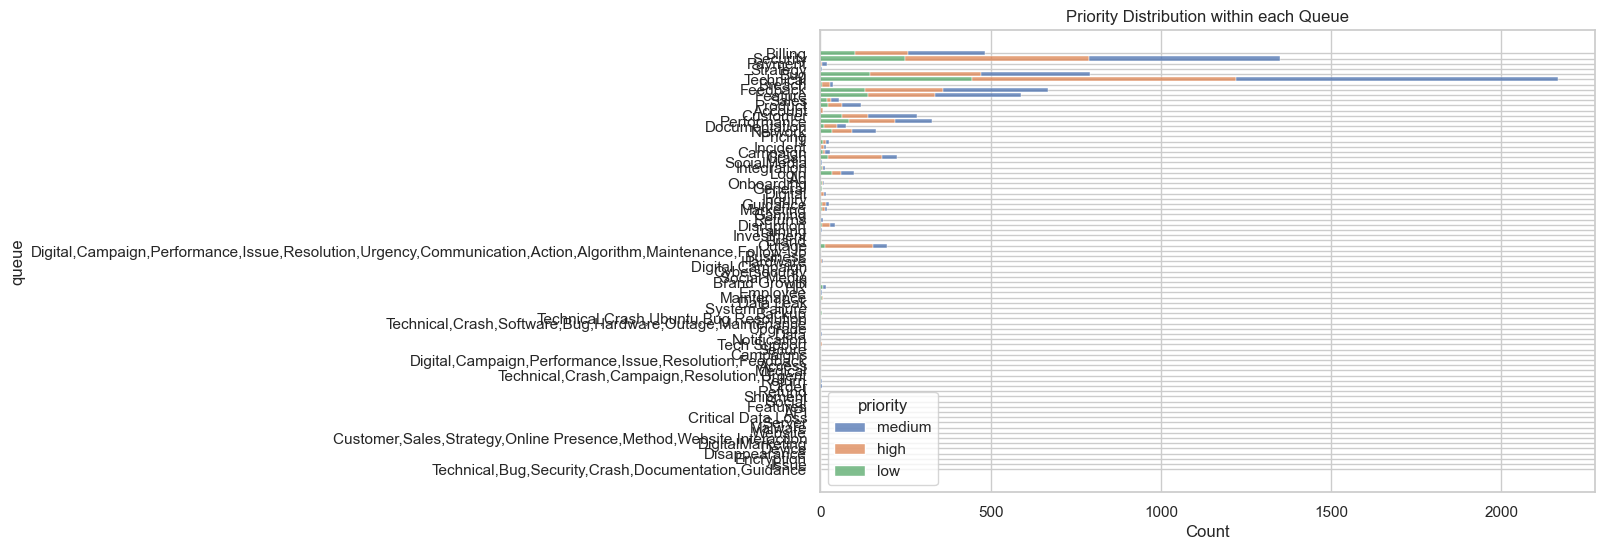

Top 5 Terms per Queue (excluding standard stopwords):
- Billing: information, issue, support, payment, billing
- Security: information, access, medical, security, data
- Payment: information, services, options, methods, payment
- Strategy: growth, contacting, strategies, digital, brand
- Bug: recent, issues, software, data, issue
- Technical: customer, problem, support, issue, data
- Breach: issue, problem, medical, breach, data
- Feedback: growth, marketing, brand, strategies, digital
- Feature: data, management, provide, project, integration
- Sales: details, services, digital, provide, information
- Product: analytics, information, support, data, tools
- Account: charges, unauthorized, support, issue, account
- Customer: strategies, customer, brand, support, digital
- Performance: server, issues, data, issue, performance
- Documentation: saas, integration, management, project, documentation
- Network: problems, issues, connectivity, issue, network
- Pricing: provide, pricing, availa

In [5]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# 1. Connect to the SQLite warehouse and map tag_1 to queue directly in SQL
conn = sqlite3.connect('../data/warehouse.db')
query = """
SELECT 
    id, subject, body, answer, type, priority, language, 
    tag_1 AS queue 
FROM tickets
"""
df = pd.read_sql_query(query, conn)
conn.close()

# Set visual style
sns.set_theme(style="whitegrid")

# 2. Ticket volume per queue and per priority
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, y='queue', order=df['queue'].value_counts().index, ax=ax1, hue='queue', legend=False)
ax1.set_title('Ticket Volume per Queue')

sns.countplot(data=df, x='priority', order=df['priority'].value_counts().index, ax=ax2, hue='priority', legend=False)
ax2.set_title('Ticket Volume per Priority')
plt.tight_layout()
plt.show()

# 3. Which queues have the longest agent answers?
df['answer_word_count'] = df['answer'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 5))
sns.barplot(data=df, y='queue', x='answer_word_count', estimator='mean', errorbar=None, hue='queue', legend=False)
plt.title('Average Agent Answer Length (Words) by Queue')
plt.show()

# 4. Which have the most high-priority tickets?
plt.figure(figsize=(10, 6))
sns.histplot(data=df, y='queue', hue='priority', multiple="stack", shrink=.8)
plt.title('Priority Distribution within each Queue')
plt.show()

# 5. Top terms per queue
print("Top 5 Terms per Queue (excluding standard stopwords):")
def get_top_terms(texts, n=5):
    vec = CountVectorizer(stop_words='english', max_features=1000)
    counts = vec.fit_transform(texts).sum(axis=0)
    vocab = {v: k for k, v in vec.vocabulary_.items()}
    top_indices = counts.argsort()[0, -n:][::-1]
    return [vocab[i.item()] for i in top_indices.A1]

# Drop any rows where 'queue' might be null before running the text analysis
df_text = df.dropna(subset=['queue'])

for queue in df_text['queue'].unique():
    try:
        terms = get_top_terms(df_text[df_text['queue'] == queue]['body'])
        print(f"- {queue}: {', '.join(terms)}")
    except ValueError:
        print(f"- {queue}: Not enough text data")